# Plot ImageNet Debug Curves

This notebook loads the five `summary.csv` files under `files/debug/` and makes two FID-only comparisons versus the number of sampling steps.

In [97]:
from pathlib import Path
import csv

import matplotlib.pyplot as plt

plt.style.use("default")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 20,
    "axes.titlesize": 24,
    "axes.labelsize": 24,
    "axes.grid": False,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "figure.titlesize": 26,
})
plt.rcParams["mathtext.fontset"] = "cm"


In [98]:
print('yes')

yes


In [99]:
repo_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

summary_paths = {
    "analytic": repo_root / "files/debug/fid5k_plain_dit_native_velocity_analytic_imagenet/summary.csv",
    "data": repo_root / "files/debug/fid5k_plain_dit_native_velocity_data_imagenet/summary.csv",
    "ddpm": repo_root / "files/debug/fid5k_plain_dit_psample_imagenet/summary.csv",
    "velocity_aligned": repo_root / "files/debug/fid5k_dit_transport_velocity_aligned_steps/summary.csv",
    "velocity_noalign": repo_root / "files/debug/fid5k_dit_transport_velocity_noalign_steps/summary.csv",
}

for name, path in summary_paths.items():
    print(f"{name}: {path}")
    print("  exists:", path.exists())

analytic: /projets/Mdesbos/yara/imeanflow/files/debug/fid5k_plain_dit_native_velocity_analytic_imagenet/summary.csv
  exists: True
data: /projets/Mdesbos/yara/imeanflow/files/debug/fid5k_plain_dit_native_velocity_data_imagenet/summary.csv
  exists: True
ddpm: /projets/Mdesbos/yara/imeanflow/files/debug/fid5k_plain_dit_psample_imagenet/summary.csv
  exists: True
velocity_aligned: /projets/Mdesbos/yara/imeanflow/files/debug/fid5k_dit_transport_velocity_aligned_steps/summary.csv
  exists: True
velocity_noalign: /projets/Mdesbos/yara/imeanflow/files/debug/fid5k_dit_transport_velocity_noalign_steps/summary.csv
  exists: True


In [100]:
def load_summary(csv_path):
    rows = []
    with csv_path.open(newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            rows.append({
                "num_steps": int(row["num_steps"]),
                "fid": float(row["fid"]),
            })
    return sorted(rows, key=lambda item: item["num_steps"])

series = {name: load_summary(path) for name, path in summary_paths.items()}
series

{'analytic': [{'num_steps': 1, 'fid': 361.3526650343107},
  {'num_steps': 2, 'fid': 331.24496099498595},
  {'num_steps': 4, 'fid': 212.9991634044959},
  {'num_steps': 8, 'fid': 51.51809086181697},
  {'num_steps': 16, 'fid': 16.21651327134157},
  {'num_steps': 32, 'fid': 9.596275677568826},
  {'num_steps': 64, 'fid': 8.203125809418566},
  {'num_steps': 250, 'fid': 7.754879171895254}],
 'data': [{'num_steps': 1, 'fid': 249.94061254799757},
  {'num_steps': 2, 'fid': 156.58341798741066},
  {'num_steps': 4, 'fid': 77.84384469408133},
  {'num_steps': 8, 'fid': 19.996032179798306},
  {'num_steps': 16, 'fid': 9.44366091387576},
  {'num_steps': 32, 'fid': 8.010907122743845},
  {'num_steps': 64, 'fid': 7.695445289042368},
  {'num_steps': 250, 'fid': 7.656952387831723}],
 'ddpm': [{'num_steps': 1, 'fid': 360.8994033721855},
  {'num_steps': 2, 'fid': 251.8281212010633},
  {'num_steps': 4, 'fid': 125.36909700893767},
  {'num_steps': 8, 'fid': 61.846818230265626},
  {'num_steps': 16, 'fid': 21.16358

In [ ]:
labels = {
    "analytic": "DDPM, $v$ analytic",
    "data": "DDPM, $v$ data",
    "ddpm": "DDPM, $\epsilon$",
    "velocity_noalign": "Transport, $v$",
    "velocity_aligned": "Transport, $v$ aligned",
}

comparison_specs = [
    {
        "names": ["ddpm", "analytic", "data"],
        "colors": {
            "ddpm": "#d62728",
            "analytic": "#ffd12a",
            "data": "#2ca02c",
        },
    },
    {
        "names": ["ddpm", "velocity_noalign", "velocity_aligned"],
        "colors": {
            "ddpm": "#d62728",
            "velocity_noalign": "#ffd12a",
            "velocity_aligned": "#2ca02c",
        },
    },
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)


for panel_idx, (ax, spec) in enumerate(zip(axes, comparison_specs)):
    for name in spec["names"]:
        rows = series[name]
        steps = [row["num_steps"] for row in rows]
        fid_values = [row["fid"] for row in rows]
        zorder = 5 if panel_idx == 1 and name == "ddpm" else 3
        ax.plot(
            steps,
            fid_values,
            marker="o",
            markersize=9,
            linewidth=3,
            color=spec["colors"][name],
            label=labels[name],
            zorder=zorder,
        )

    ax.set_xlabel("Number of steps", fontweight="bold")
    ax.set_xscale("log", base=2)
    ax.set_ylim(0, 275)
    ax.set_xticks([1, 2, 4, 8, 16, 32, 64, 250])
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

    ax.legend(
        # loc="upper left",
        # bbox_to_anchor=(0.03, 0.97),
        frameon=True,
        facecolor="#eeeeee",
        edgecolor="#888888",
        framealpha=1,
        fancybox=False,
    )

    ax.grid(
        True,
        which="major",
        linestyle="--",
        linewidth=1.0,
        color="gray",
        alpha=0.2,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_ylabel("FID-5k", fontweight="bold")

axes[1].tick_params(axis="y", labelleft=True)
plt.tight_layout()
plt.show()


In [102]:
# Optional: print the best FID from each method
for name, rows in series.items():
    best = min(rows, key=lambda row: row["fid"])
    print(f"{labels[name]}: best FID = {best['fid']:.4f} at {best['num_steps']} steps")

DDPM, $v$ analytic: best FID = 7.7549 at 250 steps
DDPM, $v$ data: best FID = 7.6570 at 250 steps
DDPM, $\epsilon$: best FID = 8.1475 at 250 steps
Transport, $v$ aligned: best FID = 8.3299 at 250 steps
Transport, $v$: best FID = 191.8459 at 4 steps


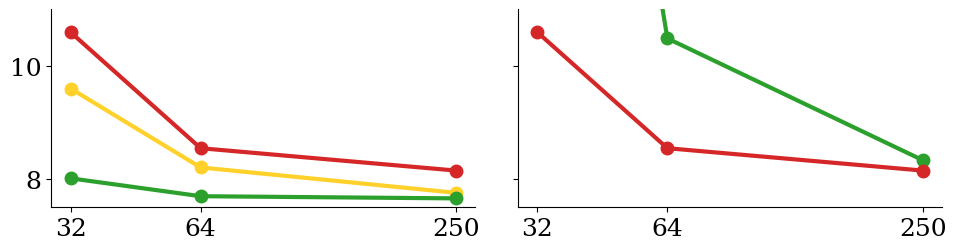

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)

for panel_idx, (ax, spec) in enumerate(zip(axes, comparison_specs)):
    for name in spec["names"]:
        rows = [row for row in series[name] if 32 <= row["num_steps"] <= 250]
        if not rows:
            continue

        steps = [row["num_steps"] for row in rows]
        fid_values = [row["fid"] for row in rows]
        zorder = 5 if panel_idx == 1 and name == "ddpm" else 3
        ax.plot(
            steps,
            fid_values,
            marker="o",
            markersize=9,
            linewidth=3,
            color=spec["colors"][name],
            label=labels[name],
            zorder=zorder,
        )

    # ax.set_title(spec["title"] + " (Zoom)", fontweight="bold")
    ax.set_xlabel("", fontweight="bold")
    ax.set_xscale("log", base=2)
    ax.set_xticks([32, 64, 250])
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.set_ylim(7.5, 11)
    # ax.legend(frameon=False)
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("", fontweight="bold")

plt.tight_layout()
plt.show()
